# Graficas del metodo de shooting (Litio)

Este notebook solo grafica los resultados producidos por `litio_shooting.f90`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
base = Path('.')
f_energy = base / 'energias_shooting_fortran.dat'
f_wave = base / 'funciones_shooting_fortran.dat'

if not f_energy.exists() or not f_wave.exists():
    raise FileNotFoundError('No se encontraron los .dat. Compila y ejecuta litio_shooting.f90 en esta carpeta.')

print('Leyendo:', f_energy)
print('Leyendo:', f_wave)

Leyendo: energias_shooting_fortran.dat
Leyendo: funciones_shooting_fortran.dat


In [3]:
dtype_energy = [('label', 'U8'), ('l', 'i4'), ('nodes', 'i4'), ('E_au', 'f8'), ('E_eV', 'f8')]
energy_data = np.genfromtxt(f_energy, comments='#', dtype=dtype_energy)

wave_data = np.loadtxt(f_wave, comments='#')
r = wave_data[:, 0]
R_labels = ['R_2s', 'R_3s', 'R_4s', 'R_2p', 'R_3p', 'R_3d']
R_cols = {name: wave_data[:, i + 1] for i, name in enumerate(R_labels)}

print('Estados encontrados:')
for row in np.atleast_1d(energy_data):
    print(f"{row['label']:>3}  l={row['l']}  nodos={row['nodes']}  E={row['E_eV']:.6f} eV")

Estados encontrados:
 2s  l=0  nodos=1  E=-9.749254 eV
 3s  l=0  nodos=2  E=-2.866874 eV
 4s  l=0  nodos=3  E=-1.345802 eV
 2p  l=1  nodos=0  E=-3.377560 eV
 3p  l=1  nodos=1  E=-1.503299 eV
 3d  l=2  nodos=0  E=-1.511618 eV


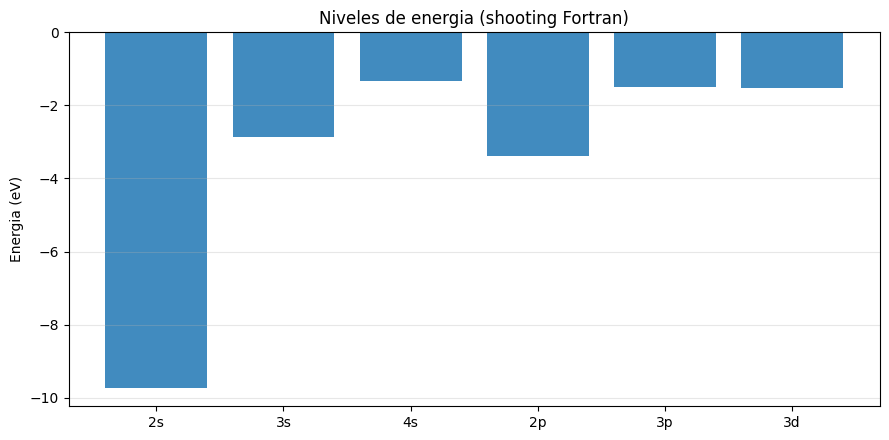

In [4]:
labels = [str(x) for x in np.atleast_1d(energy_data['label'])]
E_ev = np.atleast_1d(energy_data['E_eV'])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(labels, E_ev, color='tab:blue', alpha=0.85)
ax.set_title('Niveles de energia (shooting Fortran)')
ax.set_ylabel('Energia (eV)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

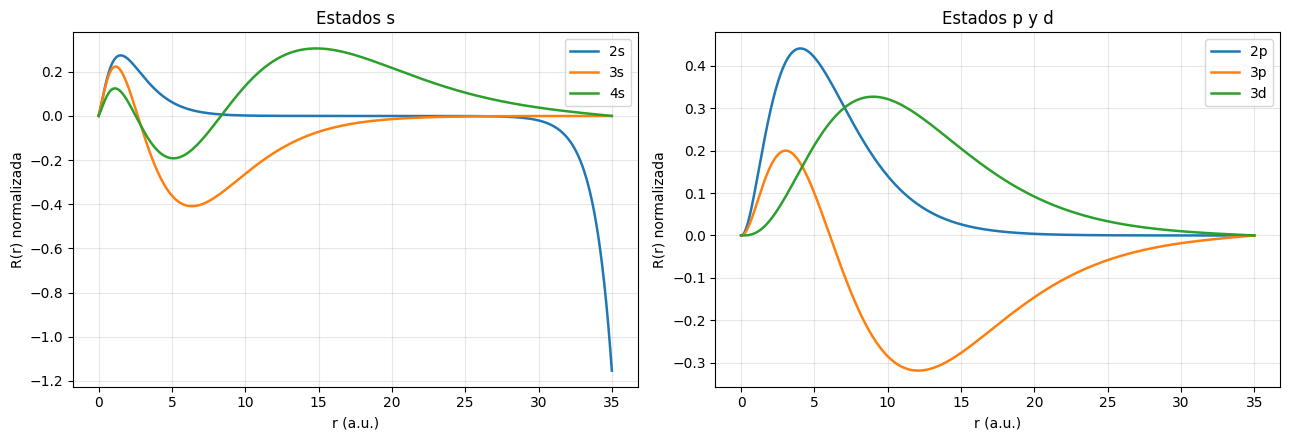

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for key in ['R_2s', 'R_3s', 'R_4s']:
    ax[0].plot(r, R_cols[key], lw=1.8, label=key[2:])
ax[0].set_title('Estados s')
ax[0].set_xlabel('r (a.u.)')
ax[0].set_ylabel('R(r) normalizada')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

for key in ['R_2p', 'R_3p', 'R_3d']:
    ax[1].plot(r, R_cols[key], lw=1.8, label=key[2:])
ax[1].set_title('Estados p y d')
ax[1].set_xlabel('r (a.u.)')
ax[1].set_ylabel('R(r) normalizada')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()